In [1]:
from podio.root_io import Reader

reader = Reader("./compton_digi.root")

Module libc not found.


Welcome to JupyROOT 6.28/06


/opt/podio/v00-17-02/python/podio/EventStore.py:4: FutureWarning: The EventStore based I/O model is deprecated and will be removed. Switch to the Frame based model.
  warnings.warn("The EventStore based I/O model is deprecated and will be removed. Switch to the Frame based model.",


In [2]:
reader.categories

('metadata', 'events', 'configuration_metadata')

In [3]:
events = reader.get("events")

In [4]:
print(f"Number of events: {len(events)}")

Number of events: 1000


In [5]:
%matplotlib widget
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import numpy as np
from RecoUtils import decodeRawHits, clusterCenter
from Hit3DBuilder import build3d

def plot3d(hits_3d, color = "blue", alpha = .8, labels = None, hide_distinct = False, ax = None):
    if ax is None:
        fig = plt.figure()
        ax = plt.axes(projection="3d")
    ax.set_xlabel('X', fontweight='bold')
    ax.set_ylabel('Y', fontweight='bold')
    ax.set_zlabel('Z', fontweight='bold')
    if labels is None:
        ax.scatter3D(hits_3d[:, 0], hits_3d[:, 1], hits_3d[:, 2], color=color, alpha = alpha)
    else:
        ax.scatter3D(hits_3d[:, 0], hits_3d[:, 1], hits_3d[:, 2], c=labels, alpha = alpha)
        centers = clusterCenter(hits_3d, labels)
        for c in centers:
            if hide_distinct and c[3] == -1:
                break
            ax.text(c[0], c[1], c[2], int(c[3]))

# First process one event

In [6]:
event = events[0]
event.collections

('TpcSimHits', 'TpcHits', 'PrimaryParticles', 'TpcWaveformHits', 'CaloHits')

In [7]:
shits = event.get("TpcSimHits")
phits = event.get("TpcHits")
whits = event.get("TpcWaveformHits")

## Process simulated space hits

In [8]:
from RecoUtils import vec3d2mat

poss = vec3d2mat(shits.position())

In [9]:
print(f"Number of trajactory points: {poss.shape[0]}")

Number of trajactory points: 198


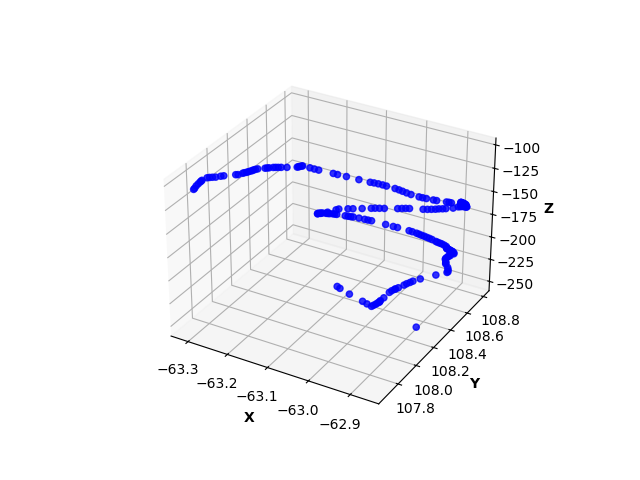

In [10]:
plot3d(poss)

## Process Tpc Hits

In [11]:
from RecoUtils import decodeRawHits

dhits = decodeRawHits(phits)

Info in <TGeoManager>: Changing system of units to Geant4 units (mm, ns, MeV).


In [12]:

print(f"""
        Number of TPC hits: {len(phits)};
        Number of x hits: {dhits.x_hits.shape[0]};
        Number of y hits: {dhits.y_hits.shape[0]}. 
      """)


        Number of TPC hits: 20;
        Number of x hits: 11;
        Number of y hits: 9. 
      


2D scatter plots to view x, y planes seperately.

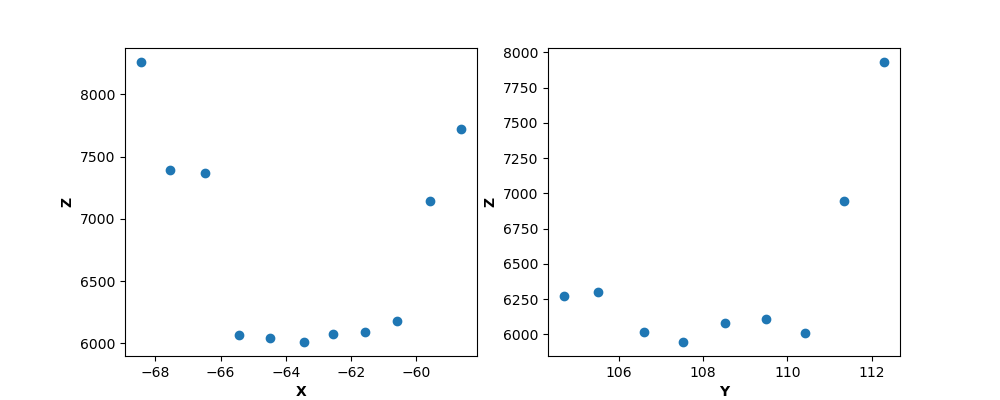

In [13]:
fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(1, 2, 1)
ax.scatter(dhits.x_hits[:,0], dhits.x_hits[:,1])
ax.set_xlabel("X", fontweight="bold")
ax.set_ylabel("Z", fontweight="bold")
ax = fig.add_subplot(1, 2, 2)
ax.scatter(dhits.y_hits[:,0], dhits.y_hits[:,1])
ax.set_xlabel("Y", fontweight="bold")
ax.set_ylabel("Z", fontweight="bold")
plt.show()

Rebuild 3D points.

In [14]:
from Hit3DBuilder import build3d

hit_pairs = build3d(dhits.x_hits, dhits.y_hits, 150, 30)

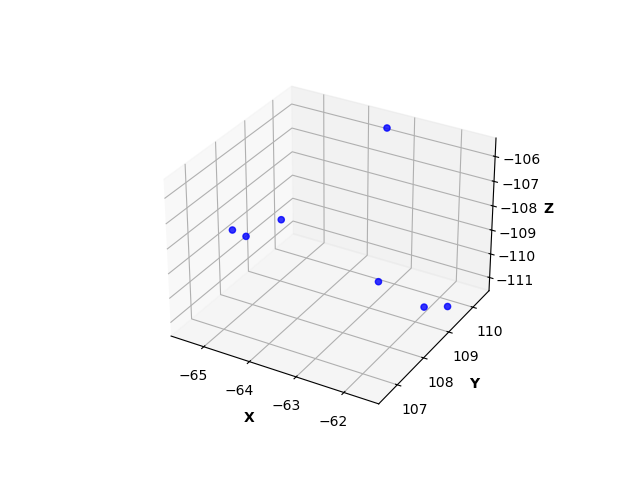

In [15]:
from RecoUtils import PairFlater
flater = PairFlater()

hits_3d = flater.toMat(hit_pairs)
plot3d(hits_3d)
plt.show()

Compare rebuilt points with trajactory points.

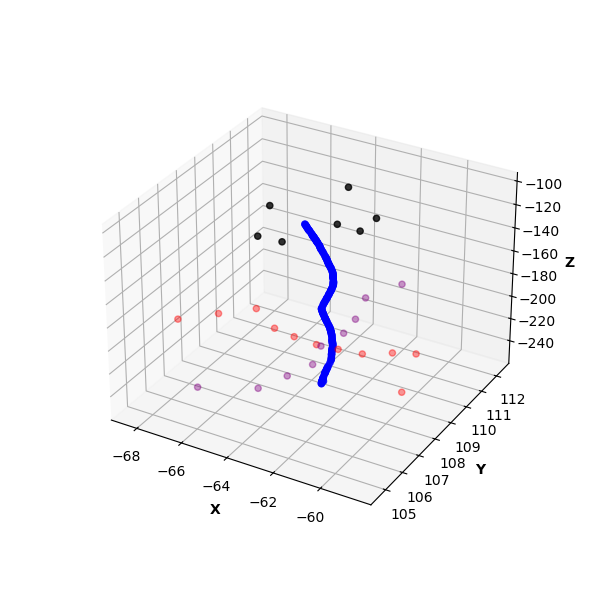

In [16]:

color_mapper = np.frompyfunc(lambda layer: ["red", "purple"][layer], 1, 1)

fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection="3d")
plot3d(hits_3d, color = "black", ax=ax)
plot3d(poss, ax=ax)
ax.scatter3D(dhits.raw_hits[:,0], 
             dhits.raw_hits[:,1], 
             dhits.raw_times / 1000 * 6 - 255, 
             c = color_mapper(dhits.layers),
             alpha = .4)
plt.show()

# Wrap in a process

Number of trajactory points: 500

        Number of TPC hits: 53;
        Number of x hits: 11;
        Number of y hits: 42. 
      


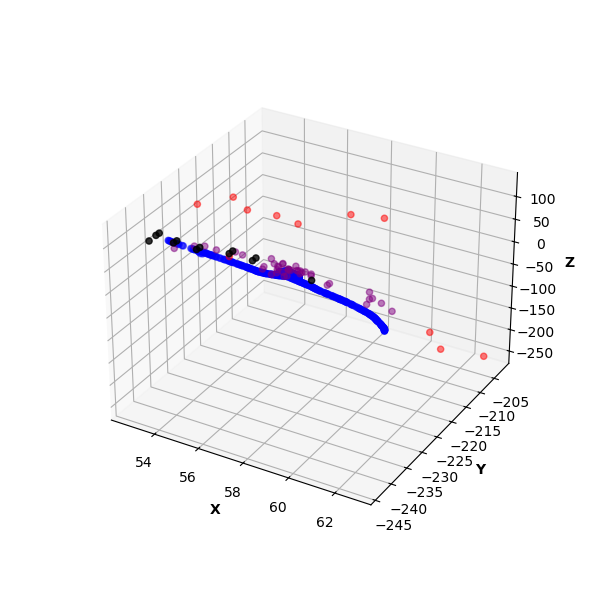

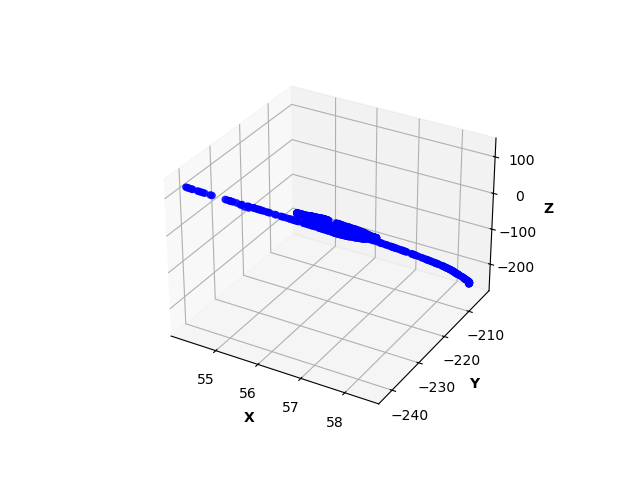

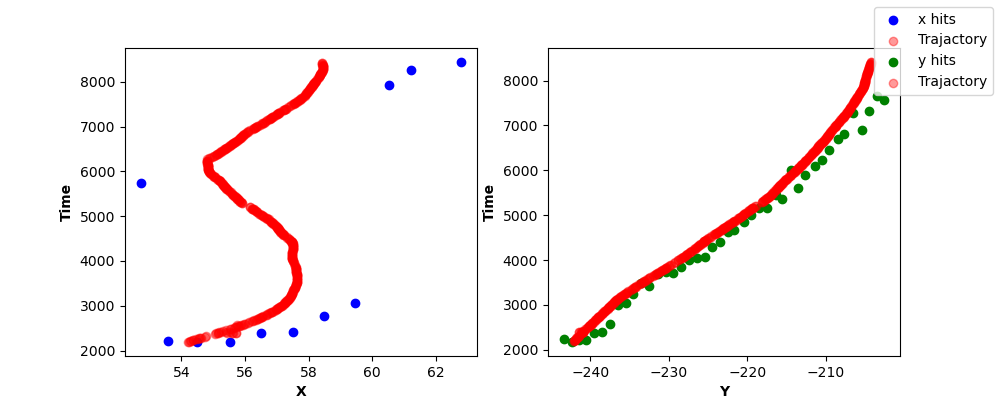

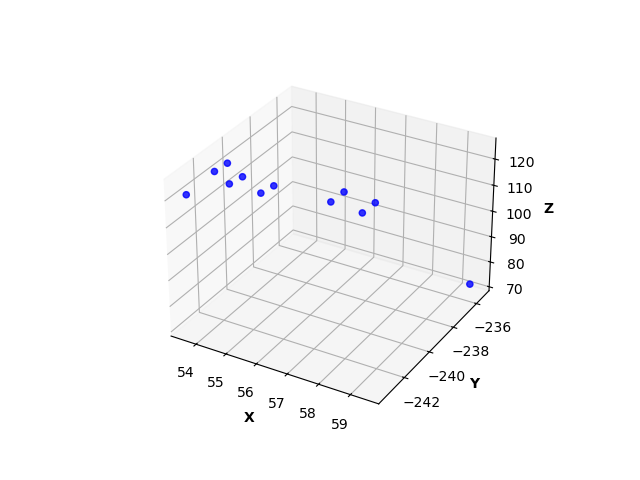

In [17]:
event = events[1]
shits = event.get("TpcSimHits")
phits = event.get("TpcHits")
whits = event.get("TpcWaveformHits")

poss = vec3d2mat(shits.position())
print(f"Number of trajactory points: {poss.shape[0]}")

dhits = decodeRawHits(phits)
print(f"""
        Number of TPC hits: {len(phits)};
        Number of x hits: {dhits.x_hits.shape[0]};
        Number of y hits: {dhits.y_hits.shape[0]}. 
      """)

plot3d(poss)

fig1 = plt.figure(figsize=(10,4))
ax1 = fig1.add_subplot(1, 2, 1)
ax1.scatter(dhits.x_hits[:,0], dhits.x_hits[:,1], 
            label="x hits", color = "blue")
ax1.scatter(poss[:,0], (255 - poss[:,2]) / 6 * 100, 
            label="Trajactory", color = "red", alpha=.4)
ax2 = fig1.add_subplot(1, 2, 2)
ax2.scatter(dhits.y_hits[:,0], dhits.y_hits[:,1], 
            label="y hits", color = "green")
ax2.scatter(poss[:,1], (255 - poss[:,2]) / 6 * 100, 
            label="Trajactory", color = "red", alpha=.4)
ax1.set_xlabel("X", fontweight="bold")
ax2.set_xlabel("Y", fontweight="bold")
ax1.set_ylabel("Time", fontweight="bold")
ax2.set_ylabel("Time", fontweight="bold")
fig1.legend()


hit_pairs = build3d(dhits.x_hits, dhits.y_hits, 150, 30)
hits_3d = flater.toMat(hit_pairs)
plot3d(hits_3d)

fig3 = plt.figure(figsize=(6, 6))
ax3 = plt.axes(projection="3d")
plot3d(hits_3d, color = "black", ax=ax3)
plot3d(poss, ax=ax3, alpha = .5)
ax3.scatter3D(dhits.raw_hits[:,0], 
             dhits.raw_hits[:,1], 
             255 - dhits.raw_times / 100 * 6, 
             c = color_mapper(dhits.layers),
             alpha = .5)

plt.show()

In [37]:
def f (i):
    event = events[i]
    shits = event.get("TpcSimHits")
    phits = event.get("TpcHits")
    whits = event.get("TpcWaveformHits")

    poss = vec3d2mat(shits.position())
    print(f"Number of trajactory points: {poss.shape[0]}")

    dhits = decodeRawHits(phits)
    print(f"""
            Number of TPC hits: {len(phits)};
            Number of x hits: {dhits.x_hits.shape[0]};
            Number of y hits: {dhits.y_hits.shape[0]}. 
        """)

    hit_pairs = build3d(dhits.x_hits, dhits.y_hits, 150, 30)
    hits_3d = flater.toMat(hit_pairs)

    # Plots
    plot3d(poss)

    fig1 = plt.figure(figsize=(10,4))
    ax1 = fig1.add_subplot(1, 2, 1)
    ax1.scatter(dhits.x_hits[:,0], 255 - dhits.x_hits[:,1] / 100 * 6, 
                label="x hits", color = "blue")
    ax1.scatter(poss[:,0], poss[:,2], 
                label="Trajactory", color = "red", alpha=.2)
    ax1.scatter(hits_3d[:,0], hits_3d[:, 2],
                label="Rebuilt", color="black", alpha = .5, marker="x")
    ax2 = fig1.add_subplot(1, 2, 2)
    ax2.scatter(dhits.y_hits[:,0], 255 - dhits.y_hits[:,1] / 100 * 6, 
                label="y hits", color = "green")
    ax2.scatter(poss[:,1], poss[:,2], 
                label="Trajactory", color = "red", alpha=.2)
    ax2.scatter(hits_3d[:,1], hits_3d[:, 2],
                label="Rebuilt", color="black", alpha = .5, marker="x")
    ax1.set_xlabel("X", fontweight="bold")
    ax2.set_xlabel("Y", fontweight="bold")
    ax1.set_ylabel("Time", fontweight="bold")
    ax2.set_ylabel("Time", fontweight="bold")
    fig1.legend()

    plot3d(hits_3d)

    fig3 = plt.figure(figsize=(6, 6))
    ax3 = plt.axes(projection="3d")
    plot3d(hits_3d, color = "black", ax=ax3)
    plot3d(poss, ax=ax3, alpha = .5)
    ax3.scatter3D(dhits.raw_hits[:,0], 
                dhits.raw_hits[:,1], 
                dhits.raw_hits[:,2] - dhits.raw_times / 100 * 6, 
                c = color_mapper(dhits.layers),
                alpha = .5)

    plt.show()

Number of trajactory points: 288

            Number of TPC hits: 24;
            Number of x hits: 12;
            Number of y hits: 12. 
        


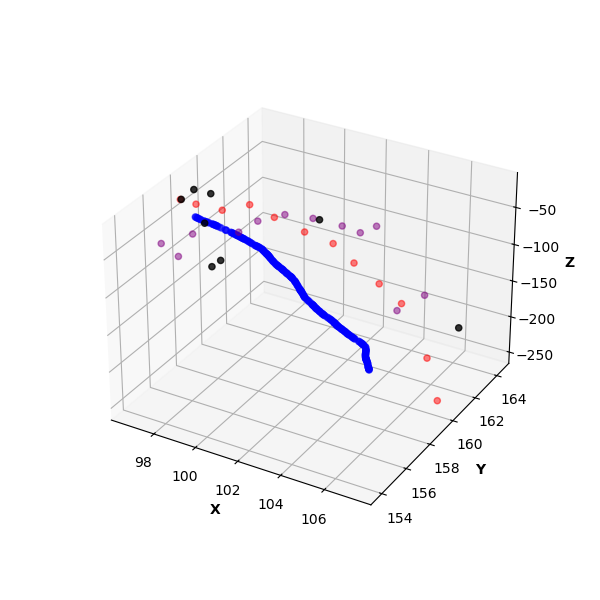

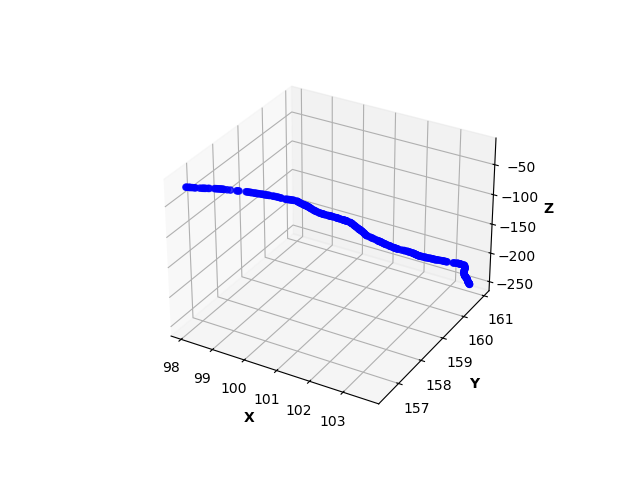

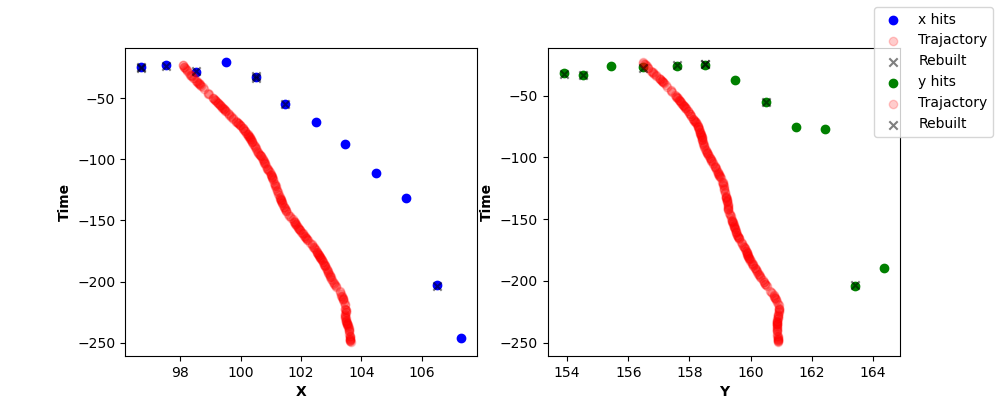

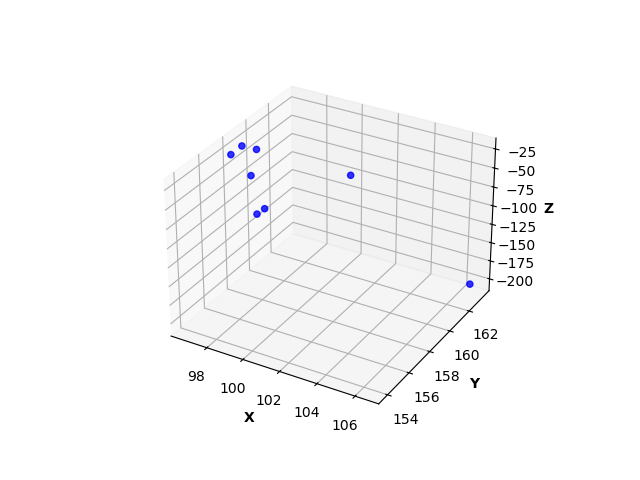

In [38]:
f(2)

Number of trajactory points: 291

            Number of TPC hits: 32;
            Number of x hits: 11;
            Number of y hits: 21. 
        


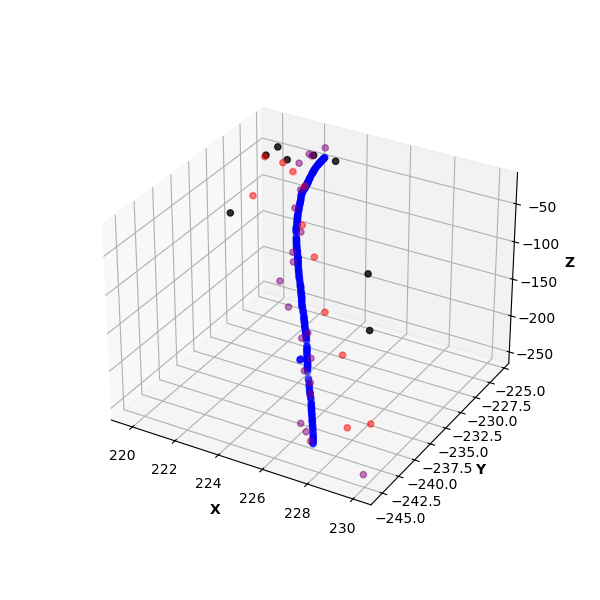

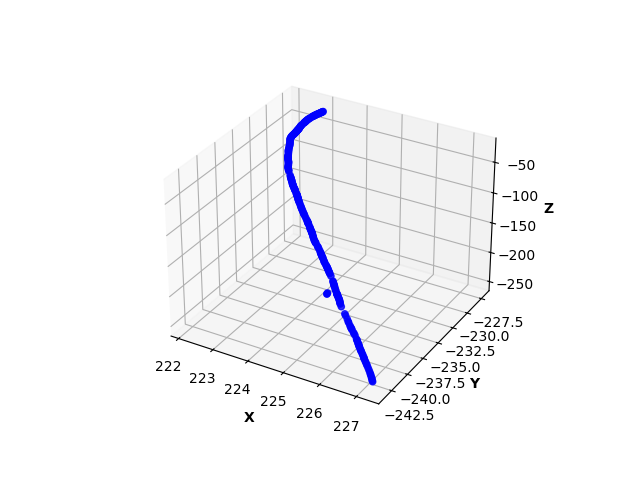

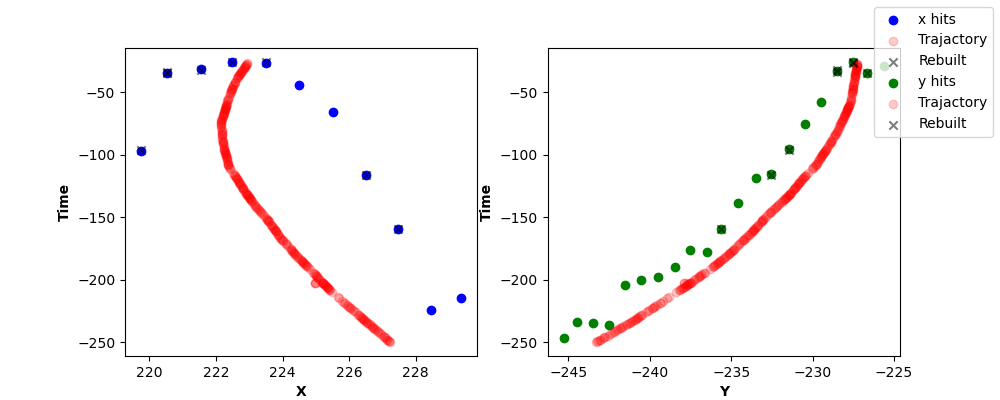

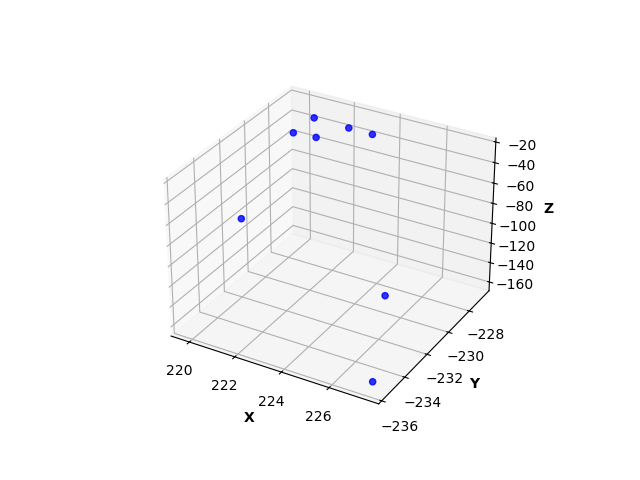

In [39]:
f(3)

Number of trajactory points: 129

            Number of TPC hits: 21;
            Number of x hits: 11;
            Number of y hits: 10. 
        


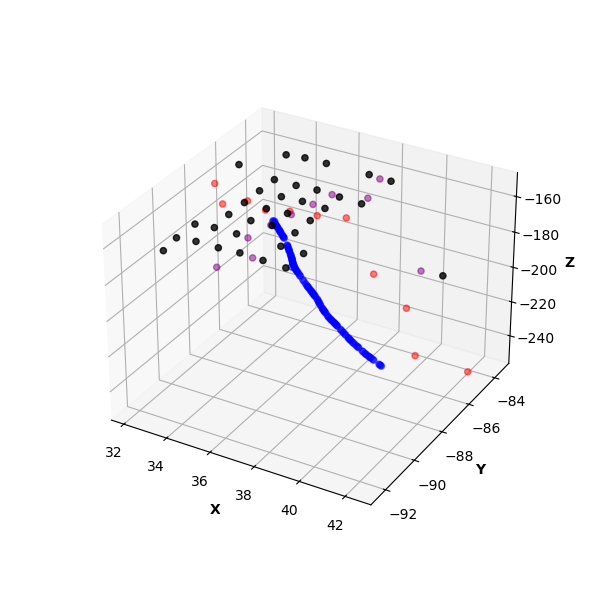

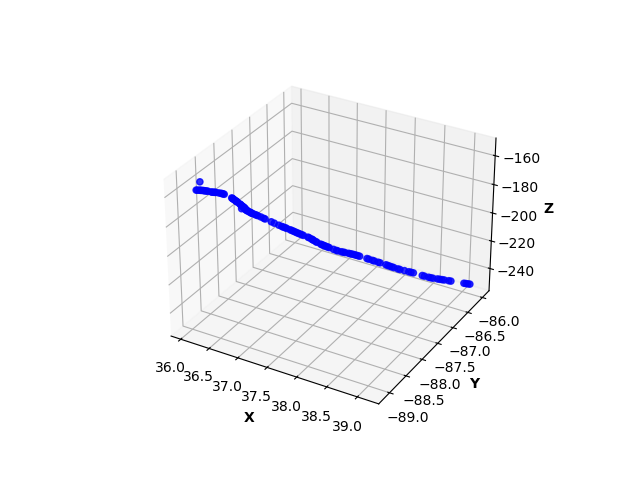

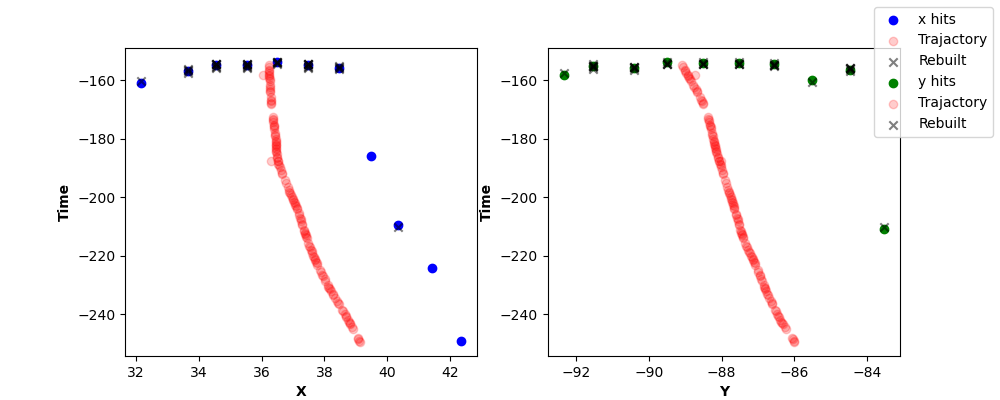

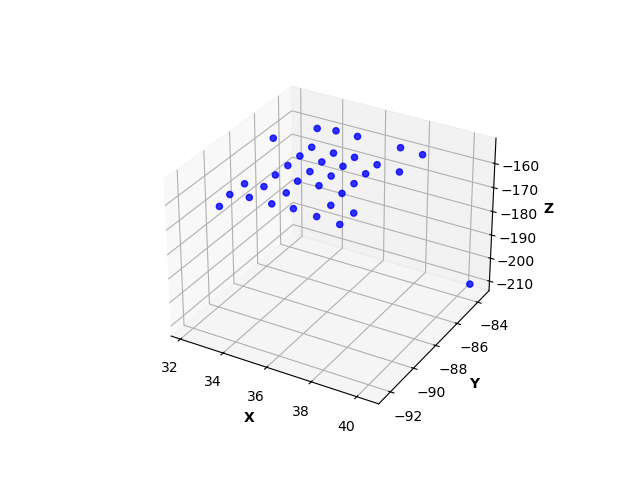

In [40]:
f(4)

Number of trajactory points: 454

            Number of TPC hits: 45;
            Number of x hits: 26;
            Number of y hits: 19. 
        


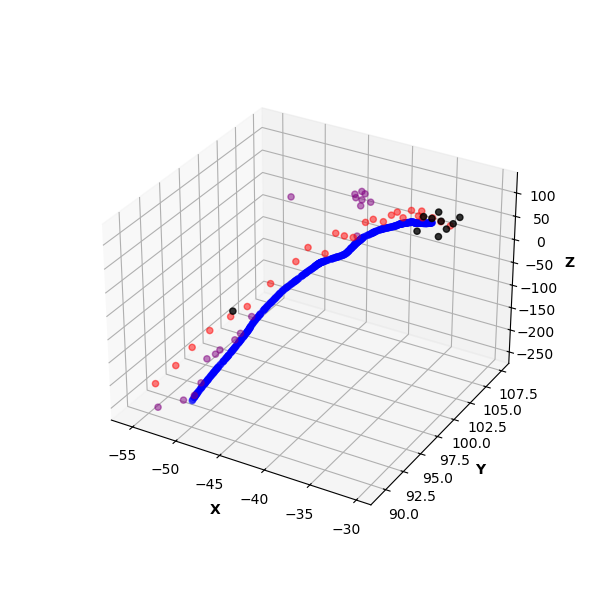

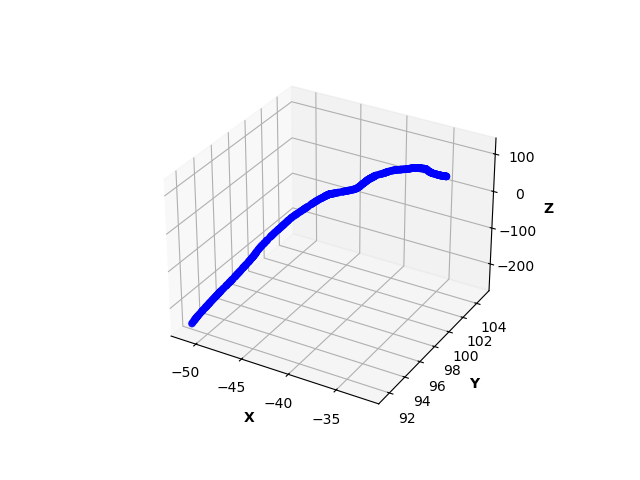

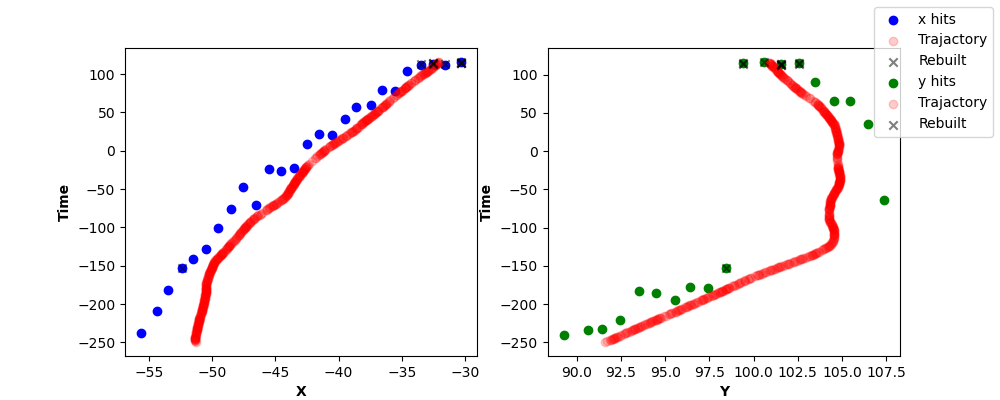

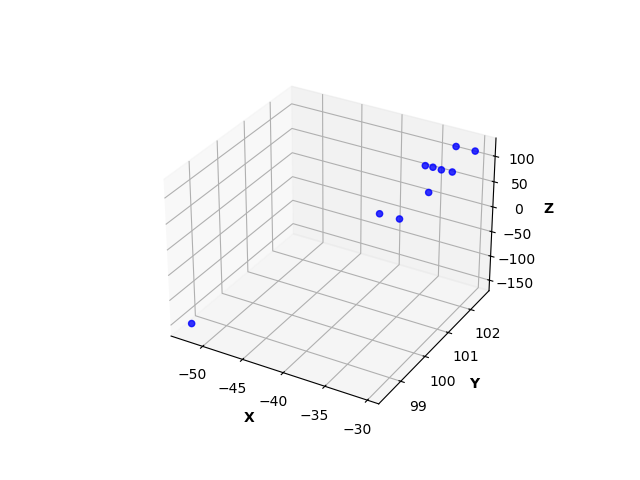

In [41]:
f(5)